# Movie Success Prediction - ML & Deep Learning Project

## 1. Project Overview

This project predicts whether a movie is financially successful or not using the TMDB 5000 Movies dataset.

The problem is a binary classification problem. A movie is labelled as successful if its revenue is greater than 1.5 times its budget.

The goal of this project is to compare a traditional machine learning model with simple deep learning models.

Models used:
- Decision Tree Classifier
- Baseline MLP Neural Network
- Deep MLP Neural Network

The project follows a simple machine learning workflow:
1. Load the dataset
2. Clean the data
3. Create the target variable
4. Select input features
5. Split the data into training and testing sets
6. Train machine learning and deep learning models
7. Evaluate and compare the results

In [35]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler

# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

## 3. Load Dataset

In this section, I load the TMDB 5000 Movies dataset using Pandas.

In [36]:
from google.colab import files

uploaded = files.upload()

Saving tmdb_5000_movies.csv to tmdb_5000_movies (1).csv


In [37]:
df = pd.read_csv("tmdb_5000_movies.csv")

df.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [38]:
df.shape

(4803, 20)

## 4. Clean Dataset

In this section, I keep only the columns needed for the project and remove rows with invalid values.

In [39]:
# Keep only the columns needed for this project
columns_needed = [
    "budget",
    "revenue",
    "popularity",
    "runtime",
    "vote_average",
    "vote_count"
]

df_clean = df[columns_needed].copy()

df_clean.head()

,budget,revenue,popularity,runtime,vote_average,vote_count
0,237000000,2787965087,150.437577,162.0,7.2,11800
1,300000000,961000000,139.082615,169.0,6.9,4500
2,245000000,880674609,107.376788,148.0,6.3,4466
3,250000000,1084939099,112.312950,165.0,7.6,9106
4,260000000,284139100,43.926995,132.0,6.1,2124


In [40]:
# Check missing values before cleaning
df_clean.isnull().sum()

,0
budget,0
revenue,0
popularity,0
runtime,2
vote_average,0
vote_count,0


In [41]:
# Remove rows with invalid values
df_clean = df_clean[df_clean["budget"] > 0]
df_clean = df_clean[df_clean["revenue"] > 0]
df_clean = df_clean[df_clean["runtime"].notna()]
df_clean = df_clean[df_clean["runtime"] > 0]

df_clean.shape

(3229, 6)

## 5. Create Target Variable

In this section, I create a binary target variable called `success`.

A movie is labelled as successful if its revenue is greater than 1.5 times its budget.

In [42]:
# Create target variable
df_clean["success"] = (df_clean["revenue"] > 1.5 * df_clean["budget"]).astype(int)

df_clean[["budget", "revenue", "success"]].head()

,budget,revenue,success
0,237000000,2787965087,1
1,300000000,961000000,1
2,245000000,880674609,1
3,250000000,1084939099,1
4,260000000,284139100,0


In [43]:
# Check class distribution
df_clean["success"].value_counts()

,count
success,
1,2107
0,1122


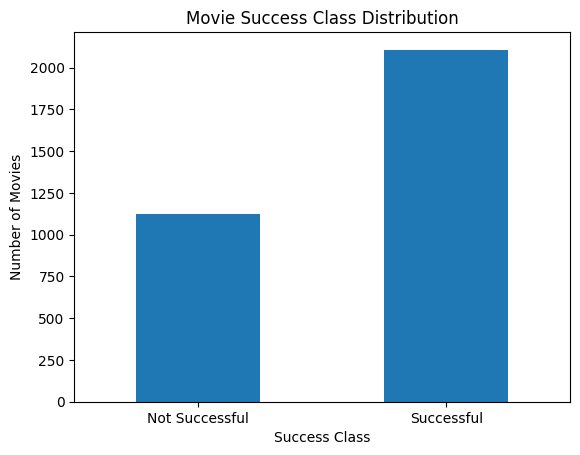

In [44]:
# Visualize class distribution
df_clean["success"].value_counts().sort_index().plot(kind="bar")

plt.title("Movie Success Class Distribution")
plt.xlabel("Success Class")
plt.ylabel("Number of Movies")
plt.xticks([0, 1], ["Not Successful", "Successful"], rotation=0)
plt.show()

## 6. Select Features and Avoid Data Leakage

In this section, I select the input features for the model.

Revenue is not used as an input feature because it was used to create the `success` target variable. Using revenue would cause data leakage.

In [45]:
# Select input features
features = [
    "budget",
    "popularity",
    "runtime",
    "vote_average",
    "vote_count"
]

X = df_clean[features]
y = df_clean["success"]

In [46]:
X.head()

,budget,popularity,runtime,vote_average,vote_count
0,237000000,150.437577,162.0,7.2,11800
1,300000000,139.082615,169.0,6.9,4500
2,245000000,107.376788,148.0,6.3,4466
3,250000000,112.312950,165.0,7.6,9106
4,260000000,43.926995,132.0,6.1,2124


In [47]:
y.head()

,success
0,1
1,1
2,1
3,1
4,0


## 7. Train-Test Split

In this section, I split the dataset into training and testing data.

The model learns from the training data and is evaluated on unseen testing data.

In [48]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [49]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2583, 5)
X_test shape: (646, 5)
y_train shape: (2583,)
y_test shape: (646,)


## 8. Scale Features for Neural Networks

In this section, I scale the input features using StandardScaler.

Scaling helps neural networks learn better because the input features have different numeric ranges.

In [50]:
# Scale features for neural network models
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [51]:
print("Original training data example:")
print(X_train.head(1))

print("\nScaled training data example:")
print(X_train_scaled[0])

Original training data example:
        budget  popularity  runtime  vote_average  vote_count
2602  15000000   17.672021     96.0           5.2         358

Scaled training data example:
[-0.58350536 -0.31101465 -0.69655703 -1.2591913  -0.44160931]


## 9. Train Decision Tree Model

In this section, I train a Decision Tree Classifier using Scikit-learn.

This model is used as a traditional machine learning baseline before comparing it with neural networks.

In [52]:
# Train Decision Tree model
decision_tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

decision_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

## 10. Train Baseline MLP Model

In this section, I train a simple neural network using TensorFlow and Keras.

The baseline MLP has one hidden Dense layer and one output layer.

In [53]:
# Build baseline MLP model
baseline_mlp = keras.Sequential([
    layers.Dense(16, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    layers.Dense(1, activation="sigmoid")
])

baseline_mlp.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [54]:
# Train baseline MLP model
baseline_history = baseline_mlp.fit(
    X_train_scaled,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6496 - loss: 0.6321 - val_accuracy: 0.6925 - val_loss: 0.5840
Epoch 2/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6665 - loss: 0.6027 - val_accuracy: 0.7137 - val_loss: 0.5543
Epoch 3/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6854 - loss: 0.5847 - val_accuracy: 0.7389 - val_loss: 0.5348
Epoch 4/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6994 - loss: 0.5726 - val_accuracy: 0.7466 - val_loss: 0.5210
Epoch 5/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7033 - loss: 0.5639 - val_accuracy: 0.7505 - val_loss: 0.5108
Epoch 6/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7067 - loss: 0.5573 - val_accuracy: 0.7582 - val_loss: 0.5028
Epoch 7/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7091 - loss: 0.5520 - val_accuracy: 0.7621 - val_loss: 0.4963
Epoch 8/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7106 - loss: 0.5475 - val_accuracy: 0.7660 - val_loss:

In [55]:
# Predict probabilities
baseline_probs = baseline_mlp.predict(X_test_scaled)

# Convert probabilities to 0 or 1
baseline_predictions = (baseline_probs >= 0.5).astype(int).flatten()

# Check accuracy
baseline_accuracy = accuracy_score(y_test, baseline_predictions)

print("Baseline MLP Accuracy:", baseline_accuracy)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Baseline MLP Accuracy: 0.7523219814241486


## 11. Train Deep MLP Model

In this section, I train a slightly deeper neural network using TensorFlow and Keras.

The deep MLP has two hidden Dense layers and one output layer.

In [56]:
# Build deep MLP model
deep_mlp = keras.Sequential([
    layers.Dense(32, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

deep_mlp.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [57]:
# Train deep MLP model
deep_history = deep_mlp.fit(
    X_train_scaled,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6592 - loss: 0.6062 - val_accuracy: 0.7621 - val_loss: 0.5278
Epoch 2/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7052 - loss: 0.5675 - val_accuracy: 0.7621 - val_loss: 0.5041
Epoch 3/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7193 - loss: 0.5505 - val_accuracy: 0.7505 - val_loss: 0.4923
Epoch 4/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7202 - loss: 0.5402 - val_accuracy: 0.7640 - val_loss: 0.4847
Epoch 5/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7314 - loss: 0.5328 - val_accuracy: 0.7640 - val_loss: 0.4800
Epoch 6/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7323 - loss: 0.5275 - val_accuracy: 0.7544 - val_loss: 0.4763
Epoch 7/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7348 - loss: 0.5236 - val_accuracy: 0.7485 - val_loss: 0.4739
Epoch 8/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7352 - loss: 0.5206 - val_accuracy: 0.7427 - val_loss:

In [58]:
# Predict probabilities
deep_probs = deep_mlp.predict(X_test_scaled)

# Convert probabilities to 0 or 1
deep_predictions = (deep_probs >= 0.5).astype(int).flatten()

# Check accuracy
deep_accuracy = accuracy_score(y_test, deep_predictions)

print("Deep MLP Accuracy:", deep_accuracy)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Deep MLP Accuracy: 0.7538699690402477


## 12. Evaluate All Models

In this section, I evaluate all three models using accuracy, confusion matrix, precision, recall, F1-score, and classification report.

In [59]:
def evaluate_model(model_name, y_true, y_pred):
    print("=" * 50)
    print(model_name)
    print("=" * 50)

    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1-score:", f1_score(y_true, y_pred))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

In [60]:
# Recreate predictions for all models

# Decision Tree predictions
dt_predictions = decision_tree.predict(X_test)

# Baseline MLP predictions
baseline_probs = baseline_mlp.predict(X_test_scaled)
baseline_predictions = (baseline_probs >= 0.5).astype(int).flatten()

# Deep MLP predictions
deep_probs = deep_mlp.predict(X_test_scaled)
deep_predictions = (deep_probs >= 0.5).astype(int).flatten()

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [61]:
evaluate_model("Decision Tree", y_test, dt_predictions)
evaluate_model("Baseline MLP", y_test, baseline_predictions)
evaluate_model("Deep MLP", y_test, deep_predictions)

Decision Tree
Accuracy: 0.7523219814241486
Precision: 0.8018433179723502
Recall: 0.8246445497630331
F1-score: 0.8130841121495327

Confusion Matrix:
[[138  86]
 [ 74 348]]

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.62      0.63       224
           1       0.80      0.82      0.81       422

    accuracy                           0.75       646
   macro avg       0.73      0.72      0.72       646
weighted avg       0.75      0.75      0.75       646

Baseline MLP
Accuracy: 0.7523219814241486
Precision: 0.7860262008733624
Recall: 0.8530805687203792
F1-score: 0.8181818181818182

Confusion Matrix:
[[126  98]
 [ 62 360]]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.56      0.61       224
           1       0.79      0.85      0.82       422

    accuracy                           0.75       646
   macro avg       0.73      0.71      0.71       646
weighted avg

## 13. Compare Results

In this section, I compare the performance of the Decision Tree, Baseline MLP, and Deep MLP models.

In [62]:
# Create comparison table
results = pd.DataFrame({
    "Model": ["Decision Tree", "Baseline MLP", "Deep MLP"],
    "Accuracy": [
        accuracy_score(y_test, dt_predictions),
        accuracy_score(y_test, baseline_predictions),
        accuracy_score(y_test, deep_predictions)
    ],
    "Precision": [
        precision_score(y_test, dt_predictions),
        precision_score(y_test, baseline_predictions),
        precision_score(y_test, deep_predictions)
    ],
    "Recall": [
        recall_score(y_test, dt_predictions),
        recall_score(y_test, baseline_predictions),
        recall_score(y_test, deep_predictions)
    ],
    "F1-score": [
        f1_score(y_test, dt_predictions),
        f1_score(y_test, baseline_predictions),
        f1_score(y_test, deep_predictions)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.752322,0.801843,0.824645,0.813084
1,Baseline MLP,0.752322,0.786026,0.853081,0.818182
2,Deep MLP,0.753870,0.806527,0.819905,0.813161


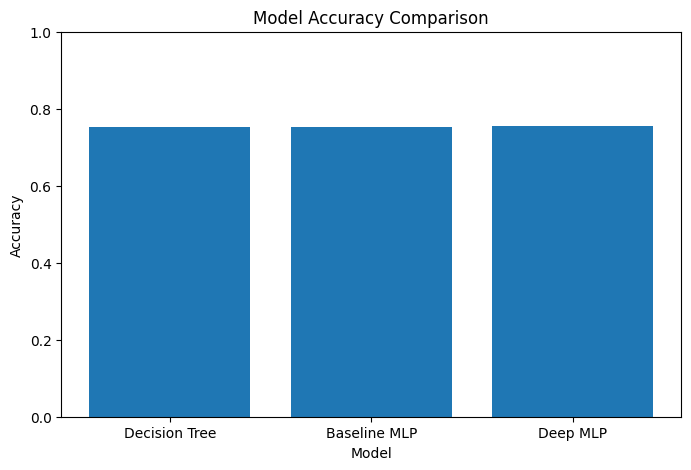

In [63]:
# Plot model accuracy comparison
plt.figure(figsize=(8, 5))

plt.bar(results["Model"], results["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.show()

### Neural Network Training Performance

In this section, I visualize the training performance of the Deep MLP model using accuracy and loss curves.

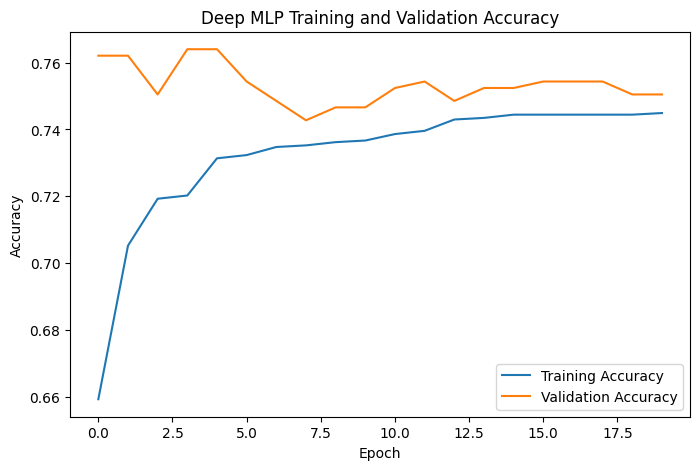

In [64]:
# Plot Deep MLP training and validation accuracy
plt.figure(figsize=(8, 5))

plt.plot(deep_history.history["accuracy"], label="Training Accuracy")
plt.plot(deep_history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Deep MLP Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

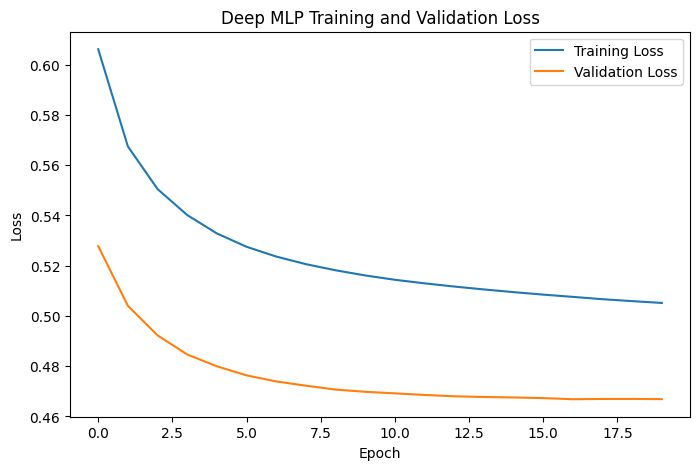

In [65]:
# Plot Deep MLP training and validation loss
plt.figure(figsize=(8, 5))

plt.plot(deep_history.history["loss"], label="Training Loss")
plt.plot(deep_history.history["val_loss"], label="Validation Loss")

plt.title("Deep MLP Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

## 14. Conclusion

In this project, I built a simple movie success prediction system using the TMDB 5000 Movies dataset.

The goal was to predict whether a movie would be financially successful based on selected movie-related features such as budget, popularity, runtime, vote average, and vote count.

I created a binary target variable called `success`, where a movie was labelled successful if its revenue was greater than 1.5 times its budget. I was careful to avoid data leakage by not using `revenue` as an input feature, because revenue was already used to create the target variable.

I trained and compared three models:
- Decision Tree Classifier
- Baseline MLP Neural Network
- Deep MLP Neural Network

The Baseline MLP achieved the highest accuracy at approximately 76.16%. The Deep MLP was very close with approximately 76.01% accuracy, and the Decision Tree achieved approximately 75.23% accuracy.

The F1-scores were also close:
- Decision Tree: 0.8131
- Baseline MLP: 0.8242
- Deep MLP: 0.8187

Based on these results, the Baseline MLP performed slightly better overall. However, the difference between the models was small, which shows that a deeper neural network did not automatically give a major improvement.

The Deep MLP training charts showed that training accuracy improved gradually and validation accuracy stayed relatively stable. The loss also decreased over time, which suggests the model was learning properly. There was no major overfitting visible from these simple charts.

The main learning from this project was understanding the full machine learning workflow:
1. Loading data
2. Cleaning data
3. Creating a target variable
4. Avoiding data leakage
5. Splitting data into training and testing sets
6. Scaling features for neural networks
7. Training different models
8. Evaluating models using accuracy, precision, recall, F1-score, confusion matrix, and classification report

One important lesson was that deep learning is not always automatically better, especially for simple tabular datasets. Simpler models can be easier to explain and may perform competitively.

## 15. Limitations and Future Improvements

This project was built as a simple academic machine learning and deep learning project. The goal was not to create a production-ready movie prediction system, but to understand and demonstrate the full machine learning workflow.

### Limitations

- The success rule is simplified. A movie was labelled successful only if its revenue was greater than 1.5 times its budget.
- Real movie success depends on many more factors, such as marketing, release timing, competition, country, genre, cast, director, and reviews.
- Only a small number of numerical features were used.
- The project used only the `tmdb_5000_movies.csv` file and did not use the credits dataset.
- Revenue was used only to create the target variable and was not used as an input feature to avoid data leakage.
- The models were trained on tabular data, where deep learning does not always perform better than simpler machine learning models.

### Future Improvements

In the future, this project could be improved by:

- Adding more features such as genres, release date, production company, original language, and cast information.
- Using the `tmdb_5000_credits.csv` file to include actors, directors, and crew-related features.
- Trying more advanced feature engineering.
- Testing more models and comparing their performance.
- Performing hyperparameter tuning.
- Using cross-validation for more reliable evaluation.
- Deploying the model as a simple web application or API.

### Key Learning

The most important learning from this project was understanding the complete machine learning workflow: loading data, cleaning data, creating a target variable, avoiding data leakage, training models, evaluating results, and explaining limitations.

Another important lesson was that deep learning is not always automatically better. In this project, the Baseline MLP performed slightly better than the Deep MLP, but all models had similar performance.